# Stage 5: Utterance Feature Vector and Intent Classification

This stage aggregates the per-frame features developed in Stages 0-4 (energy, zero-crossing rate, voicing, pitch, formants) into a single fixed-length feature vector per utterance, and evaluates three classifiers on the resulting 31-class intent classification task using the corpus's speaker-independent train/validation/test split.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score
from sklearn.utils.class_weight import compute_sample_weight

DATA_ROOT = "../data/fluent_speech_commands_dataset"
features = pd.read_csv(f"{DATA_ROOT}/features_cache.csv")
print(f"Total utterances: {len(features)}")
print(f"Unique intents: {features['intent'].nunique()}")
features.groupby("split").size()

Total utterances: 30043
Unique intents: 31


split
test      3793
train    23132
valid     3118
dtype: int64

## Feature vector and label preparation

Each utterance is represented by 10 summary statistics: mean and standard deviation of short-time energy, mean and standard deviation of zero-crossing rate, the fraction of frames classified voiced, mean and standard deviation of F0 over voiced frames, mean first- and second-formant frequency (tracked separately per frame, then averaged over all voiced frames rather than a small fixed subset), and utterance duration. Features are standardized (zero mean, unit variance) using statistics from the training split only, since the classifiers used below are sensitive to feature scale. The intent label is the concatenation of the action, object, and location slots.

In [2]:
feature_cols = ["mean_energy_db", "std_energy_db", "mean_zcr", "std_zcr",
                "voiced_fraction", "mean_f0", "std_f0", "mean_f1", "mean_f2", "duration_s"]

train_df = features[features["split"] == "train"].dropna(subset=feature_cols)
valid_df = features[features["split"] == "valid"].dropna(subset=feature_cols)
test_df = features[features["split"] == "test"].dropna(subset=feature_cols)

label_encoder = LabelEncoder()
label_encoder.fit(features["intent"])

X_train, y_train = train_df[feature_cols].values, label_encoder.transform(train_df["intent"])
X_valid, y_valid = valid_df[feature_cols].values, label_encoder.transform(valid_df["intent"])
X_test, y_test = test_df[feature_cols].values, label_encoder.transform(test_df["intent"])

scaler = StandardScaler().fit(X_train)
X_train_s = scaler.transform(X_train)
X_valid_s = scaler.transform(X_valid)
X_test_s = scaler.transform(X_test)

print(f"Train: {X_train_s.shape}, Valid: {X_valid_s.shape}, Test: {X_test_s.shape}")

Train: (23132, 10), Valid: (3118, 10), Test: (3793, 10)


## Classifiers

Three classifiers are compared: a majority-class baseline (predicts the most frequent training-set intent for every utterance, establishing the accuracy floor a useful classifier must exceed), a support vector machine with an RBF kernel, and a small multi-layer perceptron. For the SVM and MLP, a bounded grid search over the hyperparameters most likely to affect this feature set's separability (SVM: C, gamma; MLP: hidden layer size, L2 regularization strength) is performed, selecting the configuration with the highest validation accuracy. The test set is not used for model selection, only for final reporting.

The training set is class-imbalanced: per-intent counts range from 342 to 2296 utterances across the 31 intents. To account for this, class weighting is included as a further grid-search dimension for both classifiers, alongside the hyperparameters above. The SVM exposes this natively via its `class_weight` constructor argument (`'balanced'` reweights the misclassification penalty inversely to class frequency). `MLPClassifier` has no equivalent constructor argument, so the same inverse-frequency weighting is instead computed manually with `sklearn.utils.class_weight.compute_sample_weight` and passed as a per-sample weight to `fit`, which `MLPClassifier` incorporates directly into its loss. Because accuracy alone does not penalize a classifier for ignoring minority classes, macro-averaged F1 (the unweighted mean of per-class F1 scores, treating every intent equally regardless of frequency) is reported alongside accuracy for all three models.

In [3]:
results = {}
sw_train = compute_sample_weight("balanced", y_train)

baseline = DummyClassifier(strategy="most_frequent").fit(X_train_s, y_train)
results["Majority baseline"] = {
    "valid_acc": accuracy_score(y_valid, baseline.predict(X_valid_s)),
    "test_acc": accuracy_score(y_test, baseline.predict(X_test_s)),
    "valid_macro_f1": f1_score(y_valid, baseline.predict(X_valid_s), average="macro"),
    "test_macro_f1": f1_score(y_test, baseline.predict(X_test_s), average="macro"),
}

# Two selections are tracked per classifier from the same grid of fitted models: the
# configuration with the highest validation accuracy, and the configuration with the
# highest validation macro-F1. Accuracy-based selection cannot reward class weighting,
# since weighting trades some majority-class accuracy for minority-class recall; tracking
# both makes that tradeoff visible instead of asserting it.
svm_by_acc, svm_by_f1 = (None, -1, None), (None, -1, None)
for C in [1, 10, 100]:
    for gamma in ["scale", 0.01, 0.1]:
        for class_weight in [None, "balanced"]:
            m = SVC(kernel="rbf", C=C, gamma=gamma, class_weight=class_weight).fit(X_train_s, y_train)
            y_pred = m.predict(X_valid_s)
            acc = accuracy_score(y_valid, y_pred)
            f1 = f1_score(y_valid, y_pred, average="macro")
            params = (C, gamma, class_weight)
            if acc > svm_by_acc[1]:
                svm_by_acc = (m, acc, params)
            if f1 > svm_by_f1[1]:
                svm_by_f1 = (m, f1, params)

svm, svm_f1sel = svm_by_acc[0], svm_by_f1[0]
print(f"Best SVM by accuracy: C={svm_by_acc[2][0]}, gamma={svm_by_acc[2][1]}, class_weight={svm_by_acc[2][2]} "
      f"(support vectors: {svm.n_support_.sum()}/{len(X_train_s)})")
print(f"Best SVM by macro-F1: C={svm_by_f1[2][0]}, gamma={svm_by_f1[2][1]}, class_weight={svm_by_f1[2][2]}")
results["SVM (accuracy-selected)"] = {
    "valid_acc": svm_by_acc[1],
    "test_acc": accuracy_score(y_test, svm.predict(X_test_s)),
    "valid_macro_f1": f1_score(y_valid, svm.predict(X_valid_s), average="macro"),
    "test_macro_f1": f1_score(y_test, svm.predict(X_test_s), average="macro"),
}
results["SVM (macro-F1-selected)"] = {
    "valid_acc": accuracy_score(y_valid, svm_f1sel.predict(X_valid_s)),
    "test_acc": accuracy_score(y_test, svm_f1sel.predict(X_test_s)),
    "valid_macro_f1": svm_by_f1[1],
    "test_macro_f1": f1_score(y_test, svm_f1sel.predict(X_test_s), average="macro"),
}

mlp_by_acc, mlp_by_f1 = (None, -1, None), (None, -1, None)
for hidden in [(64,), (128,), (64, 32)]:
    for alpha in [0.0001, 0.001]:
        for balanced in [False, True]:
            sw = sw_train if balanced else None
            m = MLPClassifier(hidden_layer_sizes=hidden, alpha=alpha, max_iter=1000, random_state=0)
            m.fit(X_train_s, y_train, sample_weight=sw)
            y_pred = m.predict(X_valid_s)
            acc = accuracy_score(y_valid, y_pred)
            f1 = f1_score(y_valid, y_pred, average="macro")
            params = (hidden, alpha, balanced)
            if acc > mlp_by_acc[1]:
                mlp_by_acc = (m, acc, params)
            if f1 > mlp_by_f1[1]:
                mlp_by_f1 = (m, f1, params)

mlp, mlp_f1sel = mlp_by_acc[0], mlp_by_f1[0]
print(f"Best MLP by accuracy: hidden_layer_sizes={mlp_by_acc[2][0]}, alpha={mlp_by_acc[2][1]}, "
      f"balanced={mlp_by_acc[2][2]} (converged after {mlp.n_iter_} iterations)")
print(f"Best MLP by macro-F1: hidden_layer_sizes={mlp_by_f1[2][0]}, alpha={mlp_by_f1[2][1]}, "
      f"balanced={mlp_by_f1[2][2]} (converged after {mlp_f1sel.n_iter_} iterations)")
results["MLP (accuracy-selected)"] = {
    "valid_acc": mlp_by_acc[1],
    "test_acc": accuracy_score(y_test, mlp.predict(X_test_s)),
    "valid_macro_f1": f1_score(y_valid, mlp.predict(X_valid_s), average="macro"),
    "test_macro_f1": f1_score(y_test, mlp.predict(X_test_s), average="macro"),
}
results["MLP (macro-F1-selected)"] = {
    "valid_acc": accuracy_score(y_valid, mlp_f1sel.predict(X_valid_s)),
    "test_acc": accuracy_score(y_test, mlp_f1sel.predict(X_test_s)),
    "valid_macro_f1": mlp_by_f1[1],
    "test_macro_f1": f1_score(y_test, mlp_f1sel.predict(X_test_s), average="macro"),
}

results_df = pd.DataFrame(results).T
results_df.columns = ["Validation accuracy", "Test accuracy", "Validation macro-F1", "Test macro-F1"]
results_df

Best SVM by accuracy: C=10, gamma=0.01, class_weight=None (support vectors: 22912/23132)
Best SVM by macro-F1: C=100, gamma=0.01, class_weight=balanced


Best MLP by accuracy: hidden_layer_sizes=(64,), alpha=0.001, balanced=False (converged after 429 iterations)
Best MLP by macro-F1: hidden_layer_sizes=(128,), alpha=0.001, balanced=False (converged after 502 iterations)


,Validation accuracy,Test accuracy,Validation macro-F1,Test macro-F1
Majority baseline,0.101988,0.104403,0.005971,0.006099
SVM (accuracy-selected),0.163566,0.165041,0.112845,0.115376
SVM (macro-F1-selected),0.123477,0.122331,0.125060,0.119949
MLP (accuracy-selected),0.151700,0.143422,0.117864,0.119922
MLP (macro-F1-selected),0.148493,0.137358,0.121566,0.118481


## Confusion matrix

The confusion matrix for the best-performing classifier on the test split is shown below, indicating which intents are most frequently confused with one another.

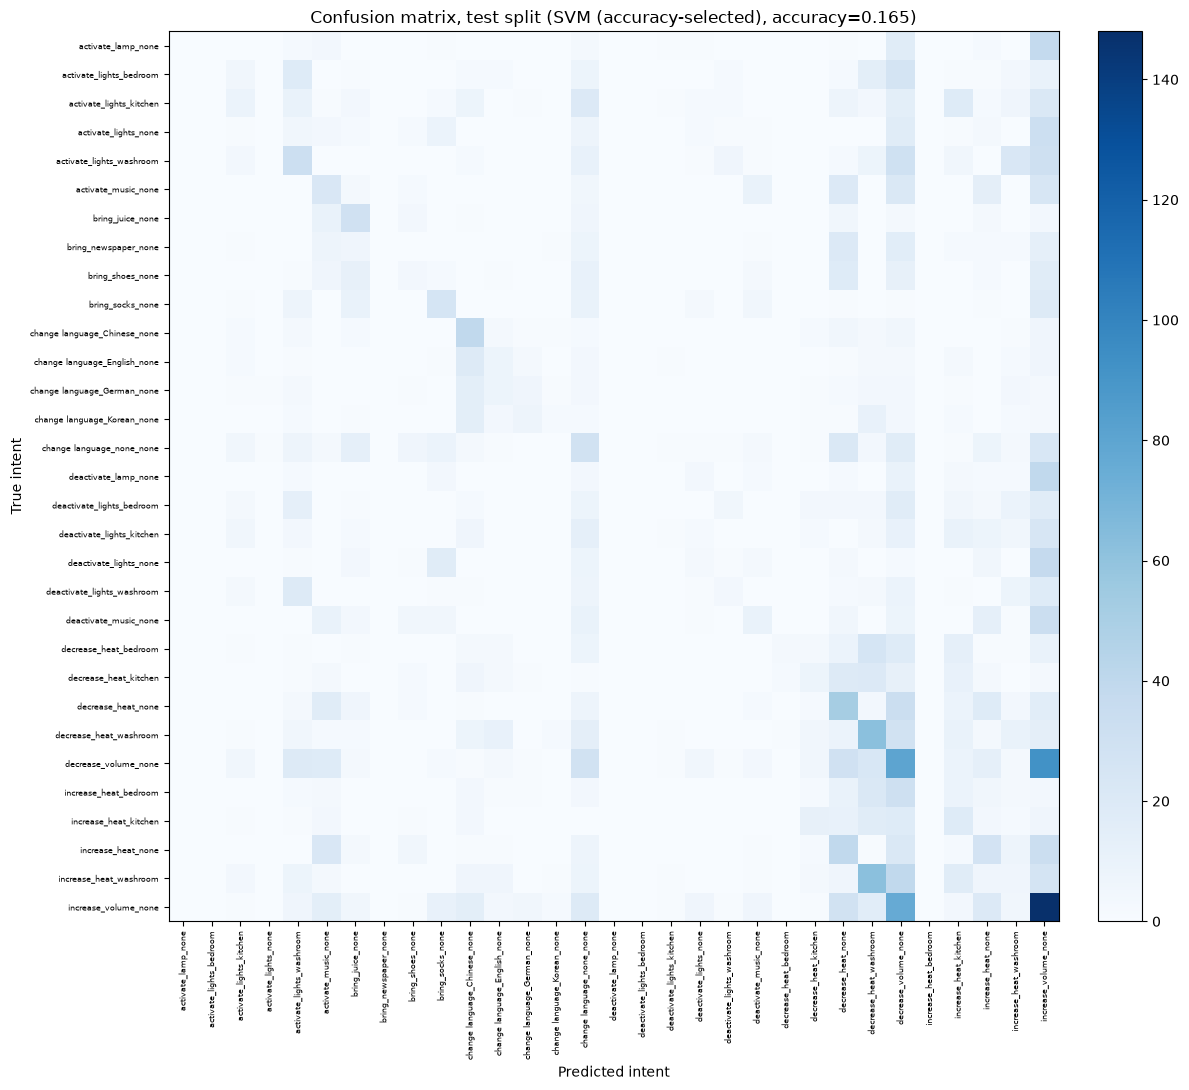

In [4]:
best_name = results_df["Test accuracy"].idxmax()
best_model = {
    "Majority baseline": baseline,
    "SVM (accuracy-selected)": svm,
    "SVM (macro-F1-selected)": svm_f1sel,
    "MLP (accuracy-selected)": mlp,
    "MLP (macro-F1-selected)": mlp_f1sel,
}[best_name]
y_pred = best_model.predict(X_test_s)
cm = confusion_matrix(y_test, y_pred, labels=np.arange(len(label_encoder.classes_)))

fig, ax = plt.subplots(figsize=(12, 11))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(len(label_encoder.classes_)))
ax.set_yticks(range(len(label_encoder.classes_)))
ax.set_xticklabels(label_encoder.classes_, rotation=90, fontsize=6)
ax.set_yticklabels(label_encoder.classes_, fontsize=6)
ax.set_xlabel("Predicted intent")
ax.set_ylabel("True intent")
best_test_acc = results_df.loc[best_name, "Test accuracy"]
ax.set_title(f"Confusion matrix, test split ({best_name}, accuracy={best_test_acc:.3f})")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
fig.tight_layout()
plt.show()

## Results

All trained classifiers exceed the majority-class baseline (10.4% test accuracy). The accuracy-selected SVM reaches 16.5% test accuracy and the accuracy-selected MLP reaches 14.3%, a relative improvement of roughly 40-60% over the baseline, but still a modest absolute accuracy on a 31-class task. This is consistent with the expected limitation of an acoustic-prosodic-only feature set (energy, zero-crossing rate, pitch, two formants, duration): the corpus's 31 intents are primarily distinguished by lexical content (which words were spoken), which this feature set does not capture. Energy, zero-crossing rate, pitch, and formant statistics carry no information about which specific words occurred; only utterance duration offers an indirect, coarse proxy, since different intents map to differently-worded phrase templates of different lengths.

Per-intent recall from the accuracy-selected SVM's confusion matrix (the best-performing model overall) is highly uneven. The best-recognized intents are "change language_Chinese_none" (52.0% recall, n=75), "bring_juice_none" (44.6%), "increase_volume_none" (37.4%), "decrease_heat_washroom" (33.0%), and "bring_socks_none" (30.1%). Eight intents have 0-1% recall, including "increase_heat_bedroom," "activate_lamp_none," and "bring_newspaper_none," which are essentially never correctly identified from acoustic-prosodic features alone. Predictions remain biased toward the most frequent training intents: "increase_volume_none" accounts for 20.3% of all test predictions despite being the true label for only 10.4% of test utterances, and "decrease_volume_none" similarly accounts for 15.9% of predictions against a true rate of 9.1%. As in the earlier feature set, "change language_Chinese_none" is comparatively well recognized in part because its phrasings are systematically longer than average (mean duration 3.06s versus an overall training-set mean of 2.29s), giving the duration feature indirect discriminative power independent of lexical content.

The training set is class-imbalanced (342 to 2296 utterances per intent across the 31 classes), and the prediction bias observed above is the expected symptom. Class weighting was evaluated as a remedy for both classifiers under two separate model-selection criteria applied to the same grid of fitted models: highest validation accuracy (as used above), and highest validation macro-averaged F1, which weights every intent equally regardless of frequency. For the SVM, class weighting is selected when optimizing for macro-F1 (C=100, `class_weight='balanced'`), but at a substantial accuracy cost: test accuracy falls from 16.5% to 12.2%, while test macro-F1 rises only marginally, from 0.115 to 0.120. For the MLP, class weighting is not selected under either criterion; the configuration found to be macro-F1-optimal on the validation set (`hidden_layer_sizes=(128,)`, unweighted) does not generalize to a macro-F1 improvement on the test set (0.118, versus 0.120 for the accuracy-selected configuration) — a direct illustration of validation-set model selection not guaranteeing a held-out improvement on the metric it was chosen for. Across all four trained classifiers, test macro-F1 varies only narrowly (0.115-0.120), while test accuracy varies far more widely (12.2%-16.5%); on this feature set, class weighting does not yield a clearly worthwhile improvement, and the unweighted, accuracy-selected SVM remains the strongest model by both metrics considered jointly.

These results support rather than undermine the feature-driven premise of this project: a classifier restricted to acoustic-prosodic summary statistics performs only modestly better than chance on what is fundamentally a lexical classification task. The improvement from averaging formants over all voiced frames rather than the 3 loudest frames (SVM: 13.7% to 16.5%) confirms that feature quality within this acoustic-prosodic family still mattered, but the underlying ceiling is structural: this is the expected consequence of omitting spectral/phonetic content (e.g. MFCCs) from the feature set, which is outside the current course scope and noted as pending work.